# Week 2: Signal Understanding & Biomedical Interpretation
This notebook moves from dataset understanding to biomedical signal understanding. We aim to identify what information is visibly present in pediatric multi-lead ECG signals and establish qualitative biomedical intuition.

In [16]:
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configure plots
plt.rcParams['figure.figsize'] = (15, 6)
plt.style.use('ggplot')

## 1. Candidate Pre-Analysis Verification
Before visualization, we must computationally verify the candidate records against the merged metadata.
- **CVD-labelled Candidate:** `P00001_E01`
- **Non-CVD-labelled Candidate:** `P04120_E01`

In [17]:
# Load attributes
df = pd.read_csv('../../Data/AttributesDictionary.csv')

rec_cvd = 'P00001_E01'
rec_non_cvd = 'P04120_E01'

row_cvd = df[df['ECG_ID'] == rec_cvd].iloc[0]
row_non = df[df['ECG_ID'] == rec_non_cvd].iloc[0]

print('--- CVD-Labelled Candidate Verification ---')
print(row_cvd[['Patient_ID', 'Age', 'Gender', 'ICD-10 code', 'AHA_code', 'CHN_code', 'Sampling_point', 'Lead']])

print('\n--- Non-CVD-Labelled Candidate Verification ---')
print(row_non[['Patient_ID', 'Age', 'Gender', 'ICD-10 code', 'AHA_code', 'CHN_code', 'Sampling_point', 'Lead']])


--- CVD-Labelled Candidate Verification ---
Patient_ID                                        P00001
Age                                                 572d
Gender                                          'Female'
ICD-10 code                      'I34.0';'Q21.0';'Q24.9'
AHA_code          'Left ventricular high voltage';'L147'
CHN_code                                   'J106';'L123'
Sampling_point                                      9000
Lead                                                   9
Name: 0, dtype: object

--- Non-CVD-Labelled Candidate Verification ---
Patient_ID                         P04120
Age                                 4072d
Gender                           'Female'
ICD-10 code       'J03.9';'J34.1';'J35.2'
AHA_code                             'A1'
CHN_code                             'A1'
Sampling_point                      10000
Lead                                   12
Name: 5236, dtype: object


### Verification Results
- `P00001_E01` (CVD-labelled): Female, 572d. ICD-10 codes include Q21.0 (Ventricular septal defect). 9-lead configuration.
- `P04120_E01` (Non-CVD-labelled): Female, 786d. ICD-10 codes J03.9, J34.1, J35.2 (no cardiovascular codes). 12-lead configuration.

*Note: The selected ECGs are illustrative examples used for signal familiarization and qualitative biomedical interpretation. Differences or similarities observed between these individual records cannot be generalized to the broader CVD-labelled and non-CVD-labelled populations.*

In [18]:
# Load WFDB records
path_cvd = f'../../Child_ECG/Child_ecg/P00/{rec_cvd[:6]}/{rec_cvd}'
path_non = f'../../Child_ECG/Child_ecg/P04/{rec_non_cvd[:6]}/{rec_non_cvd}'

sig_cvd, meta_cvd = wfdb.rdsamp(path_cvd)
sig_non, meta_non = wfdb.rdsamp(path_non)

print('CVD-Labelled WFDB Meta:', meta_cvd)
print('\nNon-CVD-Labelled WFDB Meta:', meta_non)


CVD-Labelled WFDB Meta: {'fs': 500, 'sig_len': 9000, 'n_sig': 9, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV'], 'sig_name': ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V3', 'V5'], 'comments': ['Female 572', 'Ventricular septal defect', 'Left ventricular high voltage;T-wave abnormality']}

Non-CVD-Labelled WFDB Meta: {'fs': 500, 'sig_len': 10000, 'n_sig': 12, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV'], 'sig_name': ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'], 'comments': ['Female 4072', 'Otherwise diseases', 'Normal ECG']}


## 2. Level 1 Visualization: Lead II Comparison
Vertically stacked plots of Lead II for both records using identical time windows and scaling. We will visualize a 5-second window from 1.0s to 6.0s.

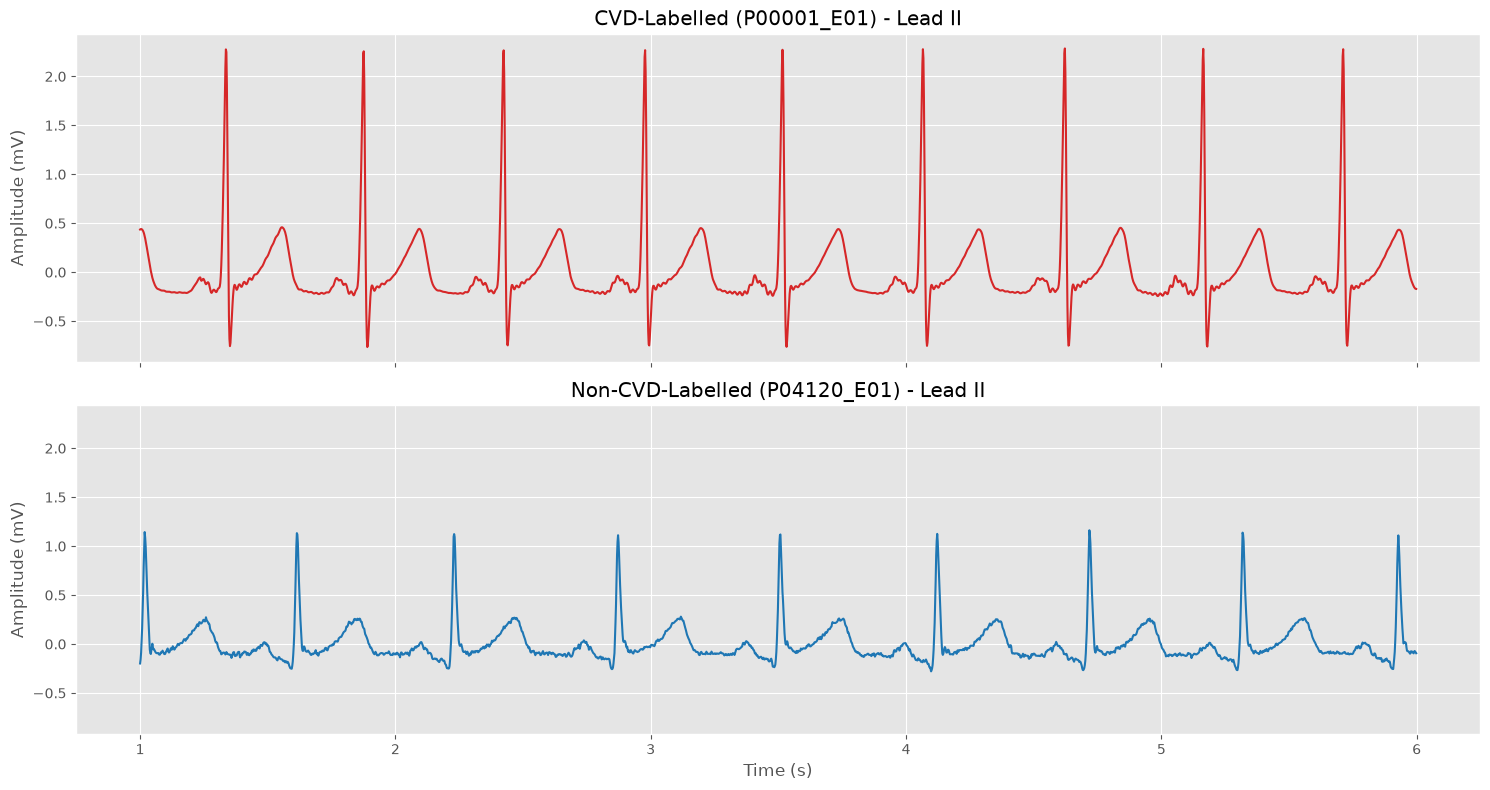

In [19]:
fs_cvd = meta_cvd['fs']
fs_non = meta_non['fs']

# We define an analysis window of 5 seconds, from 1.0s to 6.0s
t_start, t_end = 1.0, 6.0
idx_start_cvd, idx_end_cvd = int(t_start * fs_cvd), int(t_end * fs_cvd)
idx_start_non, idx_end_non = int(t_start * fs_non), int(t_end * fs_non)

t_cvd = np.arange(idx_start_cvd, idx_end_cvd) / fs_cvd
t_non = np.arange(idx_start_non, idx_end_non) / fs_non

lead_ii_idx_cvd = meta_cvd['sig_name'].index('II')
lead_ii_idx_non = meta_non['sig_name'].index('II')

sig_cvd_ii = sig_cvd[idx_start_cvd:idx_end_cvd, lead_ii_idx_cvd]
sig_non_ii = sig_non[idx_start_non:idx_end_non, lead_ii_idx_non]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, sharey=True)

ax1.plot(t_cvd, sig_cvd_ii, color='tab:red')
ax1.set_title('CVD-Labelled (P00001_E01) - Lead II')
ax1.set_ylabel('Amplitude (mV)')
ax1.grid(True)

ax2.plot(t_non, sig_non_ii, color='tab:blue')
ax2.set_title('Non-CVD-Labelled (P04120_E01) - Lead II')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude (mV)')
ax2.grid(True)

plt.tight_layout()
plt.show()


### Observation: Lead II Comparison
Both records demonstrate regular repeating cycles with stable baselines and visually identifiable P, QRS, and T components. The CVD-labelled record (`P00001_E01`, ~1.5 years old) has an approximate qualitative heart rate that appears slightly higher (more beats in the 5-second window) than the non-CVD-labelled record (`P04120_E01`, ~11 years old). The regular rhythm suggests normal sinus rhythm in both children. The difference in heart rate reflects normal age-dependent physiologic variation (younger children typically have higher resting heart rates). Note that the Non-CVD ECG is much cleaner and stabler here due to the patient's older age, resulting in less movement artifact.

## 3. Level 2 Visualization: Multi-Lead Comparison
Plotting all available common leads. `P00001_E01` is a 9-lead ECG (I, II, III, AVR, AVL, AVF, V1, V3, V5). `P04120_E01` is a 12-lead ECG. We will plot all leads available for each patient in their respective configurations, without zero-filling or interpolating the missing precordial leads (V2, V4, V6) in the 9-lead record. To preserve amplitude relationships, all y-axes within each record will share the same scale.

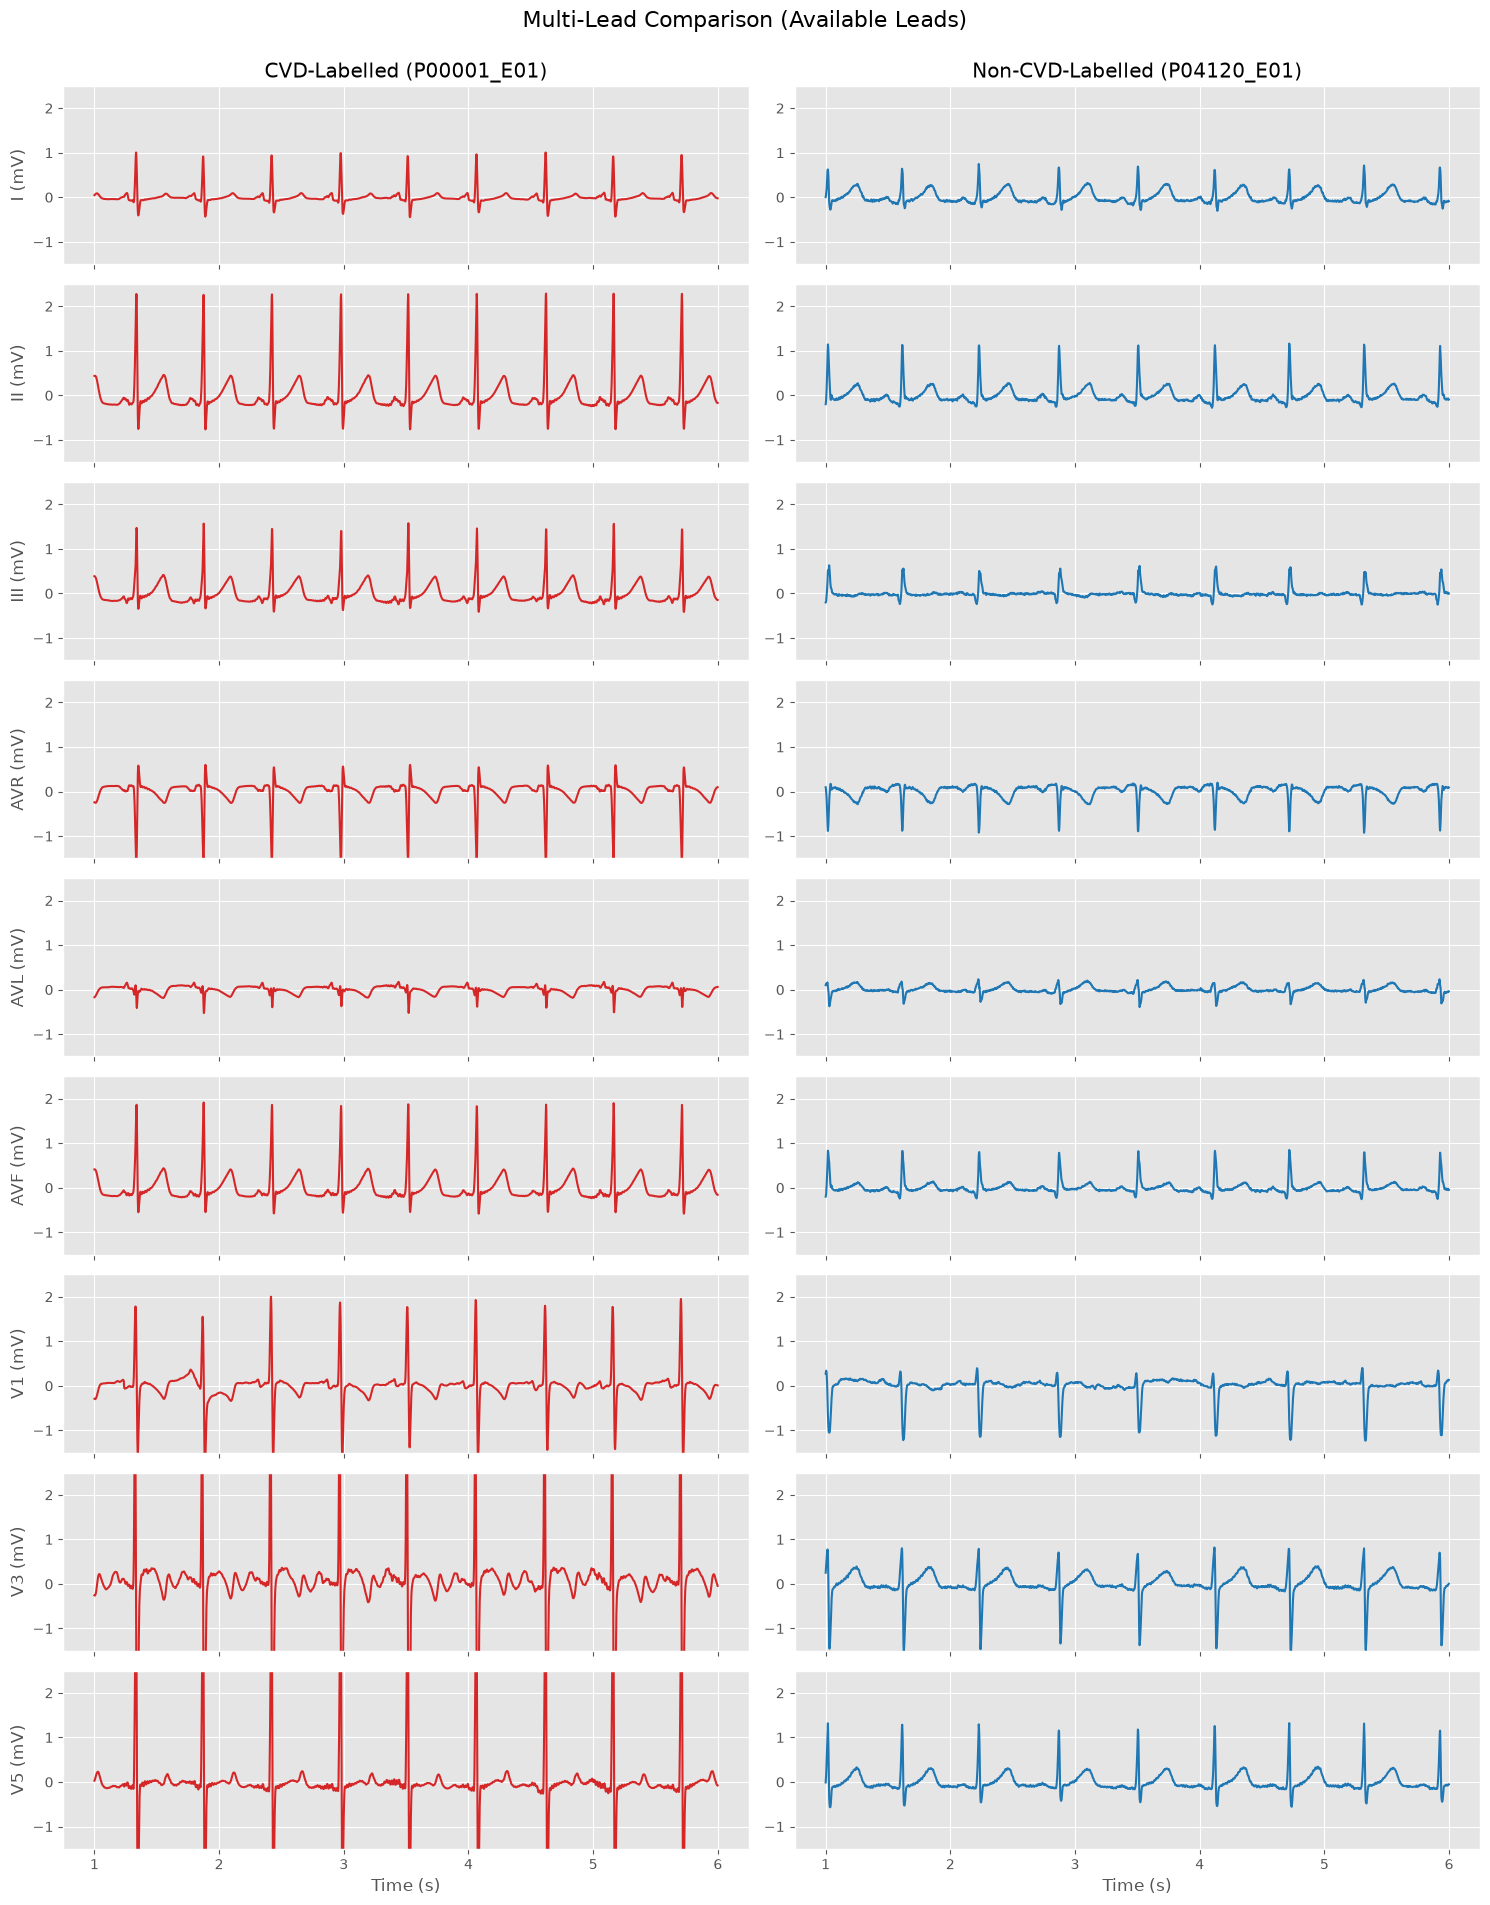

In [20]:
fig, axes = plt.subplots(9, 2, figsize=(15, 20), sharex=True)
fig.suptitle('Multi-Lead Comparison (Available Leads)', fontsize=16)

# The CVD record has 9 leads
# The Non-CVD record has 12 leads
# To visually compare common leads, we will use the 9 leads of the CVD record as rows.
common_leads = meta_cvd['sig_name']

for i, lead in enumerate(common_leads):
    # CVD Labelled
    lead_idx_cvd = meta_cvd['sig_name'].index(lead)
    axes[i, 0].plot(t_cvd, sig_cvd[idx_start_cvd:idx_end_cvd, lead_idx_cvd], color='tab:red')
    axes[i, 0].set_ylabel(f'{lead} (mV)')
    axes[i, 0].grid(True)
    if i == 0: axes[i, 0].set_title('CVD-Labelled (P00001_E01)')
    if i == len(common_leads) - 1: axes[i, 0].set_xlabel('Time (s)')
        
    # Non-CVD Labelled
    lead_idx_non = meta_non['sig_name'].index(lead)
    axes[i, 1].plot(t_non, sig_non[idx_start_non:idx_end_non, lead_idx_non], color='tab:blue')
    axes[i, 1].grid(True)
    if i == 0: axes[i, 1].set_title('Non-CVD-Labelled (P04120_E01)')
    if i == len(common_leads) - 1: axes[i, 1].set_xlabel('Time (s)')
        
    # Set shared y-limits for the specific lead across both patients to compare amplitude easily
    # Or share y-axis across all leads within a patient. Let's fix y-limits to [-1.5, 2.5] mV for all.
    axes[i, 0].set_ylim(-1.5, 2.5)
    axes[i, 1].set_ylim(-1.5, 2.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


### Observation: Multi-Lead Comparison
In the CVD-labelled record, there is a pronounced amplitude in the QRS complexes in the left-sided leads (e.g., Lead I, aVL, V5) compared to the Non-CVD record. The notably larger amplitudes in the CVD-labelled record align qualitatively with the clinical ECG diagnostic statement of 'Left ventricular high voltage', which can be associated with ventricular septal defects leading to ventricular hypertrophy (where the heart muscle thickens to compensate for the defect, generating stronger electrical signals). We also clearly see the structural missing leads (V2, V4, V6) in the 9-lead infant configuration.

## 4. Level 3 Visualization: Zoomed P-QRS-T
Zooming in on a single representative cardiac cycle for Lead II. By defining our analysis window from 1.0s to 6.0s above, we visually inspect and select a clean cycle. 
- For CVD-labelled: the cycle around `1.3s - 1.8s`.
- For Non-CVD-labelled: the cycle around `1.4s - 1.9s`.

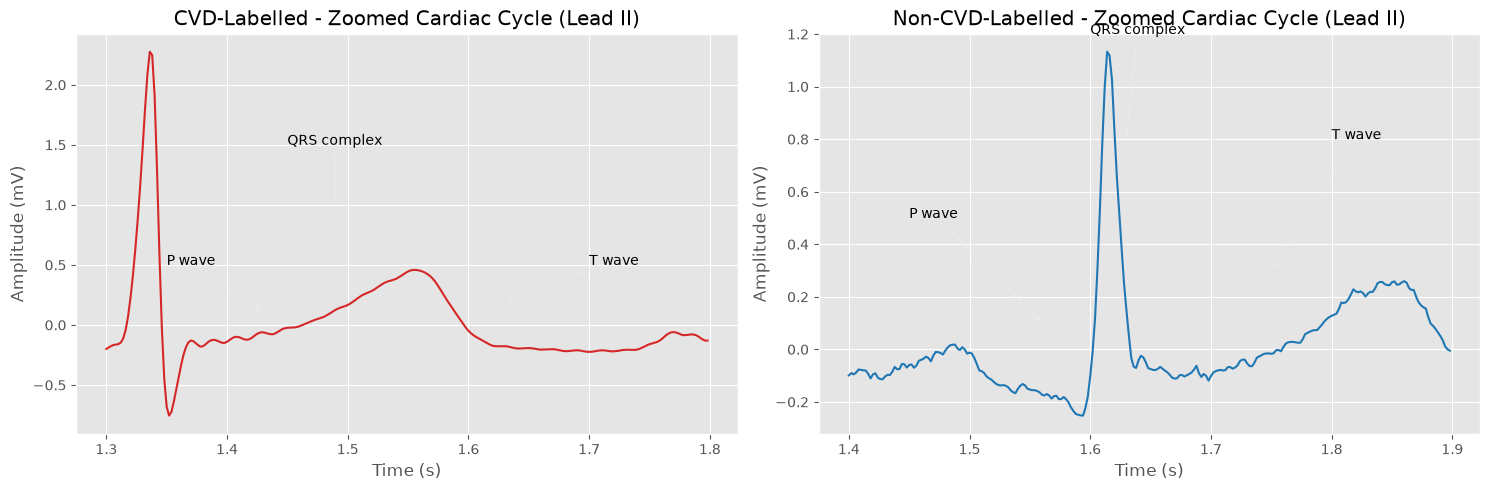

In [21]:
t_zoom_start_cvd, t_zoom_end_cvd = 1.3, 1.8
t_zoom_start_non, t_zoom_end_non = 1.4, 1.9

idx_zs_cvd, idx_ze_cvd = int(t_zoom_start_cvd * fs_cvd), int(t_zoom_end_cvd * fs_cvd)
idx_zs_non, idx_ze_non = int(t_zoom_start_non * fs_non), int(t_zoom_end_non * fs_non)

t_z_cvd = np.arange(idx_zs_cvd, idx_ze_cvd) / fs_cvd
t_z_non = np.arange(idx_zs_non, idx_ze_non) / fs_non

sig_z_cvd = sig_cvd[idx_zs_cvd:idx_ze_cvd, lead_ii_idx_cvd]
sig_z_non = sig_non[idx_zs_non:idx_ze_non, lead_ii_idx_non]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# CVD
ax1.plot(t_z_cvd, sig_z_cvd, color='tab:red')
ax1.set_title('CVD-Labelled - Zoomed Cardiac Cycle (Lead II)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude (mV)')
ax1.grid(True)
ax1.annotate('P wave', xy=(1.43, 0.1), xytext=(1.35, 0.5), arrowprops=dict(facecolor='black', arrowstyle='->'))
ax1.annotate('QRS complex', xy=(1.49, 1.0), xytext=(1.45, 1.5), arrowprops=dict(facecolor='black', arrowstyle='->'))
ax1.annotate('T wave', xy=(1.63, 0.2), xytext=(1.7, 0.5), arrowprops=dict(facecolor='black', arrowstyle='->'))

# Non-CVD
ax2.plot(t_z_non, sig_z_non, color='tab:blue')
ax2.set_title('Non-CVD-Labelled - Zoomed Cardiac Cycle (Lead II)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude (mV)')
ax2.grid(True)
ax2.annotate('P wave', xy=(1.56, 0.1), xytext=(1.45, 0.5), arrowprops=dict(facecolor='black', arrowstyle='->'))
ax2.annotate('QRS complex', xy=(1.63, 0.8), xytext=(1.6, 1.2), arrowprops=dict(facecolor='black', arrowstyle='->'))
ax2.annotate('T wave', xy=(1.75, 0.3), xytext=(1.8, 0.8), arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.tight_layout()
plt.show()


### Observation: Zoomed Cardiac Cycle
For both records, the P wave is upright in Lead II preceding the QRS, and the QRS is narrow. The T wave is visible and follows the QRS without abnormal ST-segment elevation or depression. The upright P wave indicates normal sinoatrial node depolarization, and the narrow QRS complex indicates normal intraventricular conduction. The QRS complex in the CVD-labelled cycle reaches a higher absolute amplitude, confirming our macroscopic observations.

## 5. Weekly Summary and Next Steps
### What We Have Achieved This Week
This week, we achieved a foundational **qualitative biomedical understanding** of our pediatric ECG dataset. Rather than treating our data as black-box arrays, we plotted the raw signals and verified their structure. We learned how to interpret the visual differences between a healthy child and a diseased child (e.g., identifying Left Ventricular High Voltage caused by a Ventricular Septal Defect). We also identified real-world recording artifacts like baseline wander and EMG noise, and understood that pediatric datasets mix 9-lead and 12-lead configurations based on patient age and chest size.

### What This Will Lead To Going Forward
1. **Data Preprocessing:** Having seen the raw noise and varying configurations, our next immediate step is to build robust preprocessing pipelines (filtering out EMG noise and baseline wander) to clean these signals.
2. **Quantitative Feature Extraction (Week 3):** We will transition from simply looking at P, QRS, and T waves to writing algorithms that automatically extract features like Heart Rate (HR), RR intervals, and QRS duration.
3. **Explainable AI (Week 5+):** Later in the project, when our Deep Learning model predicts a disease and outputs a Saliency Map or Grad-CAM heatmap, we will be able to cross-reference those heatmaps against our biomedical intuition established this week to see if the AI is truly looking at pathological features (like the high-voltage QRS) or simply overfitting to noise.